In [10]:
# model_selection_eval.py
# -*- coding: utf-8 -*-
"""
功能：
1. 读取广告原始数据
2. 特征工程（去掉无关字段，构造 X, y）
3. 比较 LightGBM / XGBoost / RandomForest
4. 自动选择最优模型并训练
5. 增加评估指标：RMSE、R²、MAE、MAPE
6. 增加性能指标：训练时间、预测时间
7. 可视化：预测值 vs 真实值散点图、残差分布图
"""

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
import warnings
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 设置中文字体（适配 macOS，可改成 SimHei）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
warnings.filterwarnings("ignore")

# ========== RMSE scorer ==========
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# ========== 模型比较函数 ==========
def compare_and_select_model(X, y):
    models = {
        "LightGBM": lgb.LGBMRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0),
        "RandomForest": RandomForestRegressor(random_state=42)
    }

    results = {}
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        # ---------- 训练时间 ----------
        start_time = time.time()
        model.fit(X, y)
        train_time = time.time() - start_time

        # ---------- 预测时间 ----------
        start_time = time.time()
        y_pred = model.predict(X)
        pred_time = time.time() - start_time

        # ---------- 交叉验证 ----------
        rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
        r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
        mae_scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")

        rmse_mean = -np.mean(rmse_scores)
        r2_mean = np.mean(r2_scores)
        mae_mean = -np.mean(mae_scores)
        mape_mean = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100  # 避免除零

        results[name] = {
            "RMSE": rmse_mean,
            "R2": r2_mean,
            "MAE": mae_mean,
            "MAPE(%)": mape_mean,
            "TrainTime(s)": train_time,
            "PredTime(s)": pred_time
        }

        print(f"{name}: RMSE={rmse_mean:.4f}, R2={r2_mean:.4f}, "
              f"MAE={mae_mean:.4f}, MAPE={mape_mean:.2f}%, "
              f"TrainTime={train_time:.4f}s, PredTime={pred_time:.4f}s")

    # 选 RMSE 最小的模型
    best_model_name = min(results, key=lambda k: results[k]["RMSE"])
    print(f"\n✅ 最优模型: {best_model_name} "
          f"(RMSE={results[best_model_name]['RMSE']:.4f}, "
          f"R2={results[best_model_name]['R2']:.4f})")

    best_model = models[best_model_name]
    best_model.fit(X, y)

    return best_model, results

# ========== 可视化函数 ==========


def plot_pred_vs_true(y, y_pred, zoom_range=None, model_name="模型"):
    """
    绘制预测值 vs 真实值的散点图（含整体图和局部放大图）
    参数:
        y: 真实值 (array-like)
        y_pred: 预测值 (array-like)
        zoom_range: (xmin, xmax, ymin, ymax)，局部放大区间
        model_name: 模型名称，用于标题
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # ========== 主图 ==========
    axes[0].scatter(y, y_pred, alpha=0.6, edgecolors="k")
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
    axes[0].set_xlabel("真实值")
    axes[0].set_ylabel("预测值")
    axes[0].set_title(f"{model_name} - 全局效果")

    # ========== 局部放大图 ==========
    axes[1].scatter(y, y_pred, alpha=0.6, edgecolors="k")
    axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
    axes[1].set_xlabel("真实值")
    axes[1].set_ylabel("预测值")
    axes[1].set_title(f"{model_name} - 局部放大")

    if zoom_range:
        xmin, xmax, ymin, ymax = zoom_range
        axes[1].set_xlim(xmin, xmax)
        axes[1].set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.savefig(f"/Users/qiulianpeng/SJYS/pred_vs_true_{model_name}.png", dpi=300)
    plt.show()

def visualize_results(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred

    # ---------- 预测值 vs 真实值 ----------
    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.6, edgecolors="k")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)  # 对角线
    plt.xlabel("真实值")
    plt.ylabel("预测值")
    plt.title("预测值 vs 真实值")
    # plt.savefig("/Users/qiulianpeng/SJYS/scatter_pred_vs_true2.png", dpi=300)
    plt.close()

    # ---------- 残差分布 ----------
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=30, edgecolor="k", alpha=0.7)
    plt.xlabel("残差 (真实值 - 预测值)")
    plt.ylabel("频数")
    plt.title("残差分布图")
    # plt.savefig("/Users/qiulianpeng/SJYS/residual_distribution2.png", dpi=300)
    plt.close()

    print("📊 图表已保存: scatter_pred_vs_true.png, residual_distribution.png")

# ========== 主程序 ==========
def main():
    # 1. 读取数据
    file_path = "/Users/qiulianpeng/比赛/赛题数据(天)_组别211.xlsx"
    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()

    print("原始数据大小:", df.shape)

    # 2. 设置目标变量 y
    y = df["订单"]   # 也可以改成 "订单"

    # 3. 构造特征 X
    drop_cols = ["业绩", "订单", "活动", "渠道", "广告系列ID_h", "广告组ID_h", "date"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

    print("特征维度:", X.shape)

    # 4. 模型比较并选择最优
    best_model, results = compare_and_select_model(X, y)

    # 5. 保存结果表格
    # pd.DataFrame(results).T.to_excel("/Users/qiulianpeng/SJYS/model_comparison_results2.xlsx", index=True)
    print("📂 模型比较结果已保存到 model_comparison_results.xlsx")

    # 6. 可视化
    visualize_results(best_model, X, y)

if __name__ == "__main__":
    main()




原始数据大小: (4224, 10)
特征维度: (4224, 4)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 4224, number of used features: 4
[LightGBM] [Info] Start training from score 136.297348
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 3379, number of used features: 4
[LightGBM] [Info] Start training from score 132.011246
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 3379, number of used features:

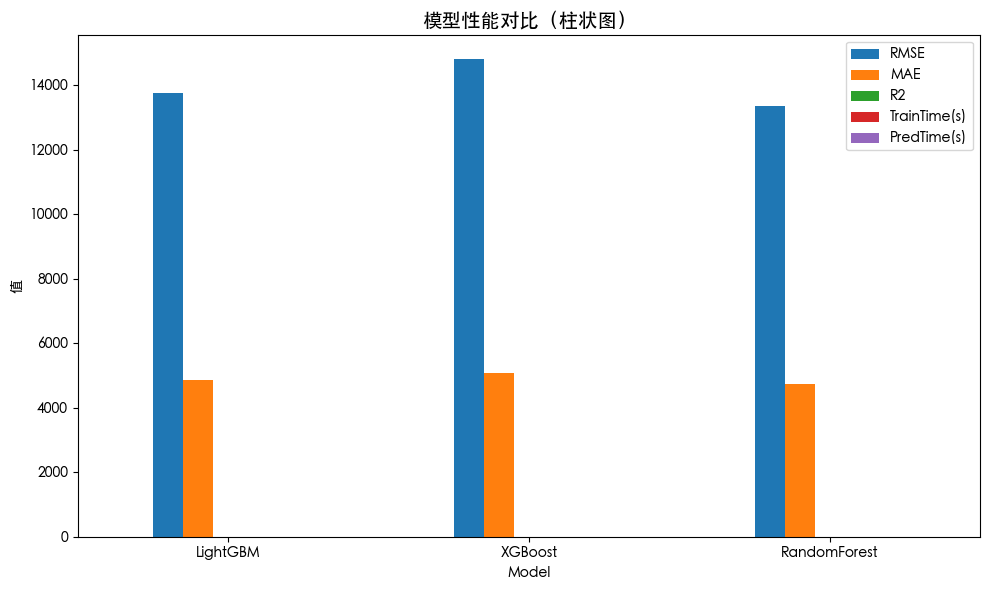

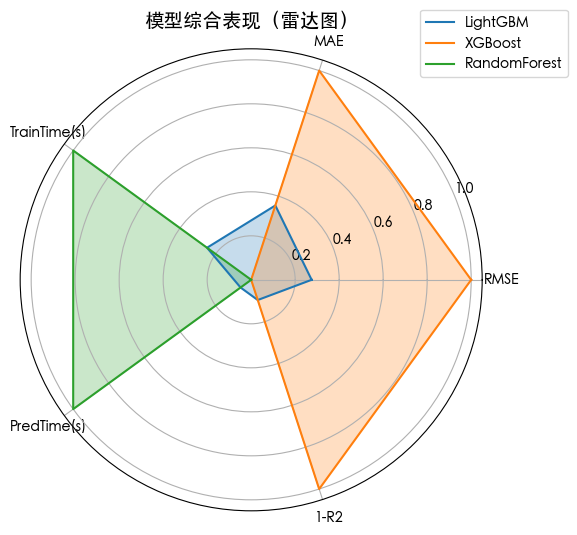

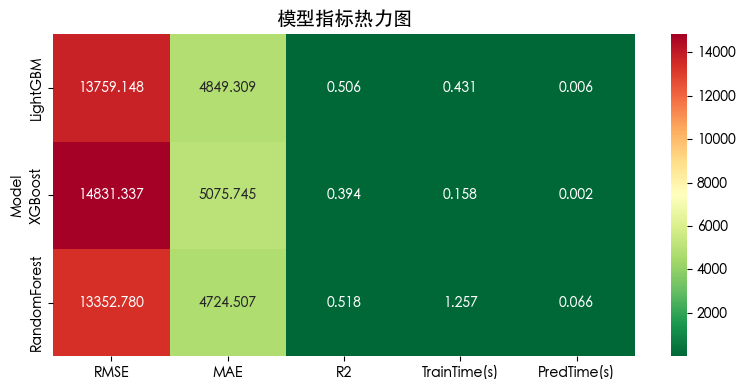

✅ 可视化完成，已保存为 model_barplot.png, model_radar.png, model_heatmap.png


In [4]:
# visualize_model_results.py
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 1. 输入结果表格
# =============================
data = {
    "Model": ["LightGBM", "XGBoost", "RandomForest"],
    "RMSE": [13759.14791, 14831.33654, 13352.77989],
    "R2": [0.506341403, 0.393667215, 0.518386452],
    "MAE": [4849.309156, 5075.745434, 4724.507344],
    "TrainTime(s)": [0.430677891, 0.158242941, 1.256784678],
    "PredTime(s)": [0.005633116, 0.001776934, 0.066452026]
}
df = pd.DataFrame(data)
df.set_index("Model", inplace=True)
 # "MAPE(%)": [4.08834E+12, 1.91038E+12, 1.99252E+12],  # ⚠️ 这个太大了，可视化时先忽略
# =============================
# 2. 分组柱状图
# =============================
metrics_to_plot = ["RMSE", "MAE", "R2", "TrainTime(s)", "PredTime(s)"]

df[metrics_to_plot].plot(kind="bar", figsize=(10, 6))
plt.title("模型性能对比（柱状图）", fontsize=14)
plt.ylabel("值")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/qiulianpeng/SJYS/model_barplot.png", dpi=300)
plt.show()

# =============================
# 3. 雷达图
# =============================
# 取 R2 的反向指标 (1 - R2)，便于“越低越好”的统一比较
df_radar = df.copy()
df_radar["1-R2"] = 1 - df_radar["R2"]

# 选取对比指标（去掉原始 R2，换成 1-R2）
radar_metrics = ["RMSE", "MAE", "TrainTime(s)", "PredTime(s)", "1-R2"]

# 归一化到 0-1
df_norm = (df_radar[radar_metrics] - df_radar[radar_metrics].min()) / \
          (df_radar[radar_metrics].max() - df_radar[radar_metrics].min())

# 绘制雷达图
labels = radar_metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # 闭合

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for model in df_norm.index:
    values = df_norm.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("模型综合表现（雷达图）", fontsize=14)
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.savefig("/Users/qiulianpeng/SJYS/model_radar.png", dpi=300)
plt.show()

# =============================
# 4. 热力图
# =============================
plt.figure(figsize=(8, 4))
sns.heatmap(df[metrics_to_plot], annot=True, fmt=".3f", cmap="RdYlGn_r", cbar=True)
plt.title("模型指标热力图", fontsize=14)
plt.tight_layout()
plt.savefig("/Users/qiulianpeng/SJYS/model_heatmap.png", dpi=300)
plt.show()

print("✅ 可视化完成，已保存为 model_barplot.png, model_radar.png, model_heatmap.png")
